In [18]:
import pandas as pd
df = pd.read_csv("hotel_bookings.csv")
print(df.head())
print("Shape of dataframe",df.shape)
print("*"*60)
print("Information of dataframe",df.info)
print("*"*60)
print("Description of the columns",df.describe())
print("*"*60)
print("Data type of the dataframe",df.dtypes)

df["is_canceled"].value_counts() #and in this 0 denotes that booking was not cancelled and vice versa

y=df["is_canceled"]
x = df.drop(columns=["is_canceled"])

# We are differentiating the numeric columns and categorical columns
numeric_columns = x.select_dtypes(include=["int64","float64"]).columns
print("*"*60)
print(numerical_columns)

print("*"*60)
categorical_cols = x.select_dtypes(include=["object","str"]).columns
print(categorical_cols)

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

,Missing Count,Missing Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350
arrival_date_month,0,0.000000
arrival_date_week_number,0,0.000000
hotel,0,0.000000
is_canceled,0,0.000000
stays_in_weekend_nights,0,0.000000
arrival_date_day_of_month,0,0.000000


Columns with more than 50% missing values:


,Missing Count,Missing Percentage
company,112593,94.306893


Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests'],
      dtype='str')


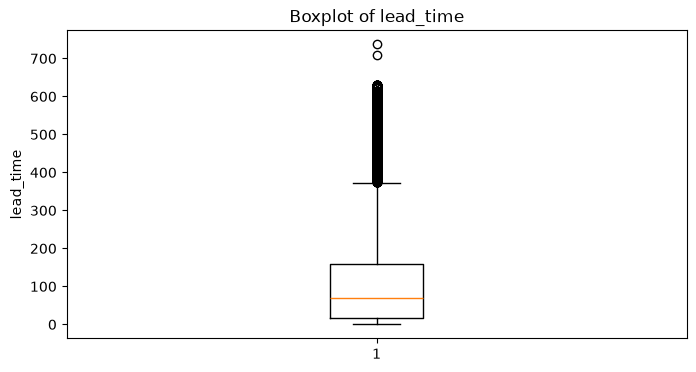

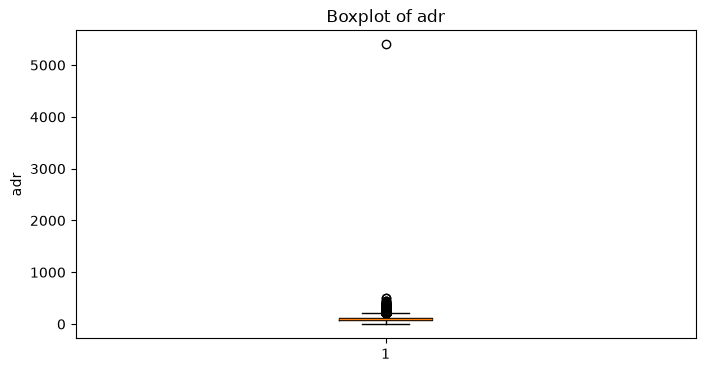

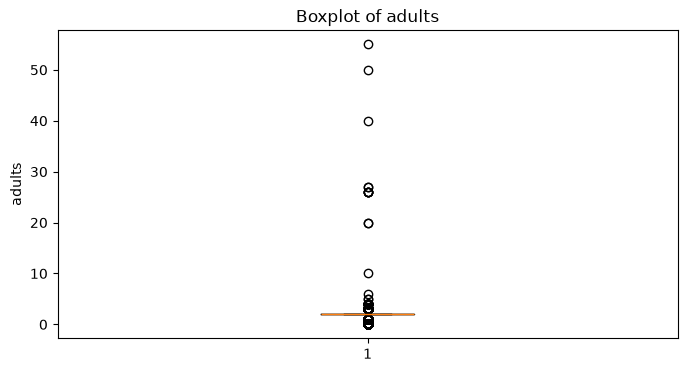

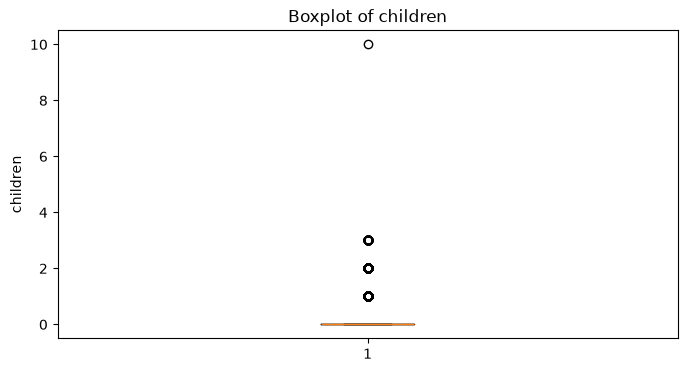

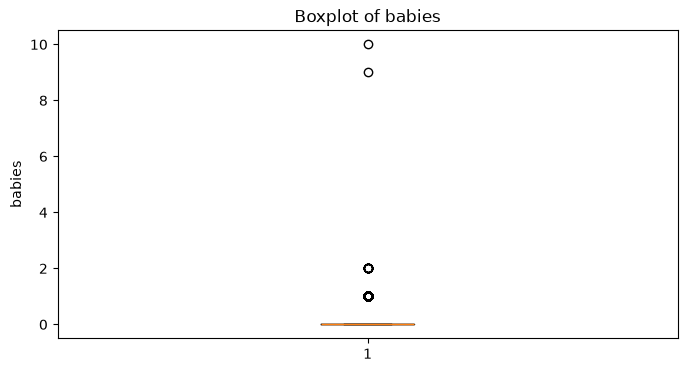


lead_time
Lower Bound: -408.0
Upper Bound: 586.0

adr
Lower Bound: -100.83999999999999
Upper Bound: 296.13

adults
Lower Bound: 2.0
Upper Bound: 2.0

children
Lower Bound: 0.0
Upper Bound: 0.0

babies
Lower Bound: 0.0
Upper Bound: 0.0
Rows before outlier removal: 119390
Rows after outlier removal: 81325
Rows removed: 38065


In [25]:
import matplotlib.pyplot as plt
missing_count = df.isna().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})
missing_summary = missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)
display(missing_summary)

high_missing = missing_summary[
    missing_summary["Missing Percentage"] > 50
]

print("Columns with more than 50% missing values:")
display(high_missing)

df = df.drop(columns=["company"])

df = df.drop(
    columns=["reservation_status", "reservation_status_date"]
)

print(df.columns)
outlier_columns = [
    "lead_time",
    "adr",
    "adults",
    "children",
    "babies"
]


for column in outlier_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[column].dropna())
    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)
    plt.show()

    outlier_bounds = {}

for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR

    outlier_bounds[column] = (lower_bound, upper_bound)

    print(f"\n{column}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")


    rows_before = len(df)

outlier_mask = pd.Series(False, index=df.index)

for column in outlier_columns:
    lower_bound, upper_bound = outlier_bounds[column]

    column_outliers = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    )

    outlier_mask = outlier_mask | column_outliers

df = df[~outlier_mask].copy()

rows_after = len(df)

rows_removed = rows_before - rows_after

print("Rows before outlier removal:", rows_before)
print("Rows after outlier removal:", rows_after)
print("Rows removed:", rows_removed)



In [ ]:
y = df["is_canceled"]

X = df.drop(
    columns=["is_canceled"]
)

print("X shape:", X.shape)
print("y shape:", y.shape)


# ------------------------------------------------------------
# TASK 3.2 - Identify Numerical and Categorical Columns
# ------------------------------------------------------------

numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_cols = X.select_dtypes(
    include=["object"]
).columns

print("\nNumerical Columns:")
print(list(numerical_cols))

print("\nCategorical Columns:")
print(list(categorical_cols))


# ------------------------------------------------------------
# TASK 3.3 - Train-Test Split
# ------------------------------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTrain-Test Split")
print("----------------")

print("X_train:", X_train.shape)

print("X_test:", X_test.shape)

print("y_train:", y_train.shape)

print("y_test:", y_test.shape)


# ------------------------------------------------------------
# TASK 3.4 - Import Preprocessing Tools
# ------------------------------------------------------------

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import (
    KNNImputer,
    SimpleImputer
)

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder
)


# ------------------------------------------------------------
# TASK 3.5 - Categorical Preprocessing
# ------------------------------------------------------------

categorical_pipeline = Pipeline([
    
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])


# ------------------------------------------------------------
# TASK 3.6 - Pipeline A Numerical Preprocessing
# KNNImputer + StandardScaler
# ------------------------------------------------------------

numeric_pipeline_A = Pipeline([
    
    (
        "imputer",
        KNNImputer(
            n_neighbors=5
        )
    ),
    
    (
        "scaler",
        StandardScaler()
    )
])


# ------------------------------------------------------------
# TASK 3.7 - Create Preprocessor A
# ------------------------------------------------------------

preprocessor_A = ColumnTransformer([
    
    (
        "num",
        numeric_pipeline_A,
        numerical_cols
    ),
    
    (
        "cat",
        categorical_pipeline,
        categorical_cols
    )
])


# ------------------------------------------------------------
# TASK 3.8 - Create Pipeline A
# ------------------------------------------------------------

pipeline_A = Pipeline([
    
    (
        "preprocessor",
        preprocessor_A
    )
])


# ------------------------------------------------------------
# TASK 3.9 - Pipeline B Numerical Preprocessing
# KNNImputer + MinMaxScaler
# ------------------------------------------------------------

numeric_pipeline_B = Pipeline([
    
    (
        "imputer",
        KNNImputer(
            n_neighbors=5
        )
    ),
    
    (
        "scaler",
        MinMaxScaler()
    )
])


# ------------------------------------------------------------
# TASK 3.10 - Create Preprocessor B
# ------------------------------------------------------------

preprocessor_B = ColumnTransformer([
    
    (
        "num",
        numeric_pipeline_B,
        numerical_cols
    ),
    
    (
        "cat",
        categorical_pipeline,
        categorical_cols
    )
])


# ------------------------------------------------------------
# TASK 3.11 - Create Pipeline B
# ------------------------------------------------------------

pipeline_B = Pipeline([
    
    (
        "preprocessor",
        preprocessor_B
    )
])


# ------------------------------------------------------------
# Verify Pipeline Structures
# ------------------------------------------------------------

print("\nPipeline A:")
print(pipeline_A)

print("\nPipeline B:")
print(pipeline_B)


Numerical Columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical Columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']

Training shape: (95512, 31)
Testing shape: (23878, 31)


KeyboardInterrupt: 

In [ ]:
# ------------------------------------------------------------
# TASK 4.1 - Import Classification Models
# ------------------------------------------------------------

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier


# ------------------------------------------------------------
# TASK 4.2 - Create Models
# ------------------------------------------------------------

logistic_regression = LogisticRegression(
    max_iter=1000
)

decision_tree = DecisionTreeClassifier(
    random_state=42
)


# ------------------------------------------------------------
# TASK 4.3 - Logistic Regression + Pipeline A
# ------------------------------------------------------------

logistic_pipeline_A = Pipeline([
    
    (
        "preprocessor",
        preprocessor_A
    ),
    
    (
        "model",
        LogisticRegression(
            max_iter=1000
        )
    )
])


# ------------------------------------------------------------
# TASK 4.4 - Logistic Regression + Pipeline B
# ------------------------------------------------------------

logistic_pipeline_B = Pipeline([
    
    (
        "preprocessor",
        preprocessor_B
    ),
    
    (
        "model",
        LogisticRegression(
            max_iter=1000
        )
    )
])


# ------------------------------------------------------------
# TASK 4.5 - Decision Tree + Pipeline A
# ------------------------------------------------------------

decision_tree_pipeline_A = Pipeline([
    
    (
        "preprocessor",
        preprocessor_A
    ),
    
    (
        "model",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])


# ------------------------------------------------------------
# TASK 4.6 - Decision Tree + Pipeline B
# ------------------------------------------------------------

decision_tree_pipeline_B = Pipeline([
    
    (
        "preprocessor",
        preprocessor_B
    ),
    
    (
        "model",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])


# ------------------------------------------------------------
# TASK 4.7 - Train Logistic Regression + Pipeline A
# ------------------------------------------------------------

print("Training Logistic Regression + Pipeline A...")

logistic_pipeline_A.fit(
    X_train,
    y_train
)

print("Completed.")


# ------------------------------------------------------------
# TASK 4.8 - Train Logistic Regression + Pipeline B
# ------------------------------------------------------------

print("\nTraining Logistic Regression + Pipeline B...")

logistic_pipeline_B.fit(
    X_train,
    y_train
)

print("Completed.")


# ------------------------------------------------------------
# TASK 4.9 - Train Decision Tree + Pipeline A
# ------------------------------------------------------------

print("\nTraining Decision Tree + Pipeline A...")

decision_tree_pipeline_A.fit(
    X_train,
    y_train
)

print("Completed.")


# ------------------------------------------------------------
# TASK 4.10 - Train Decision Tree + Pipeline B
# ------------------------------------------------------------

print("\nTraining Decision Tree + Pipeline B...")

decision_tree_pipeline_B.fit(
    X_train,
    y_train
)

print("Completed.")


# ------------------------------------------------------------
# TASK 4.11 - Verify All Four Models
# ------------------------------------------------------------

print("\n================================================")
print("ALL FOUR MODEL-PIPELINE COMBINATIONS TRAINED")
print("================================================")

print("1. Logistic Regression + Pipeline A")
print("2. Logistic Regression + Pipeline B")
print("3. Decision Tree + Pipeline A")
print("4. Decision Tree + Pipeline B")